In [ ]:
path='/kaggle/input/only-slices-with-stroke'

In [ ]:
print(os.listdir(path))

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/only-slices-with-stroke/sub-strokecase0202/mask_slice_010.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/mask_slice_005.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/mask_slice_014.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/dwi_slice_012.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/dwi_slice_014.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/mask_slice_009.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/mask_slice_012.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/dwi_slice_007.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/dwi_slice_009.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/dwi_slice_006.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/dwi_slice_010.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/mask_slice_007.png
/kaggle/input/only-slices-with-stroke/sub-strokecase0202/mask_slice_006.png
/kaggle/input/only


## Does Complexity Improve Segmentation? A Comparative Study of U-Net, Attention U-Net, and ResNet-Attention U-Net for Medical Image Segmentation

Abstract:
Deep learning models, particularly U-Net and its variants, have become the standard for medical image segmentation. In this work, we present a systematic comparison of three architectures: the baseline U-Net, an Attention U-Net, and a ResNet-based Attention U-Net. Each model was trained and validated on the same dataset, with training monitored over 50 epochs. The U-Net consistently demonstrated stable training dynamics, with validation Dice scores improving from 0.61 (epoch 2) to 0.85 (epoch 50), indicating robust convergence. In contrast, the Attention U-Net showed fluctuations in validation loss (for example, a spike at epoch 4 with Dice dropping to 0.47), reflecting sensitivity to attention gating. The ResNet-Attention U-Net achieved high training Dice (0.90) but validation remained lower (about 0.85), suggesting potential overfitting.

Final test set results further highlight these trends. The U-Net achieved the best overall performance (Dice = 0.819, IoU = 0.723, Precision = 0.930, Recall = 0.908, F1 = 0.918). The Attention U-Net improved recall (0.916) but lowered Dice (0.718) and IoU (0.621), while the ResNet-Attention U-Net achieved strong precision (0.903) but lower Dice (0.701) and IoU (0.613) compared to the baseline.

These findings demonstrate that increasing architectural complexity does not always yield better performance: while attention gates enhance sensitivity and residual connections strengthen precision, the baseline U-Net remains the most effective and balanced model for this dataset. Future work will explore hybrid approaches to combine the stability of U-Net with the recall of attention mechanisms and the precision of residual connections.


Stroke Lesion Segmentation with U-Net and Variants
--------------------------------------------------

This script implements and compares deep learning models for automatic stroke
lesion segmentation on DWI (Diffusion-Weighted Imaging) slices.

Workflow:
1. Data Loading & Preprocessing
   - Collects DWI images and corresponding binary masks.
   - Converts to grayscale, resizes to 128×128, and transforms to tensors.
   - Splits dataset into Train (70%), Validation (15%), and Test (15%).

2. Models
   - Baseline U-Net: Standard encoder-decoder with skip connections.
   - Attention U-Net: Adds attention gates to improve focus on lesion regions.
   - ResNet + U-Net: Uses a ResNet backbone as encoder for richer features.

3. Loss Function
   - Binary Cross Entropy (BCE) + Dice Loss.
   - Balances pixel-level classification with region overlap quality.

4. Metrics
   - Dice Score (overlap between predicted and true masks).
   - IoU (Intersection over Union).
   - Precision, Recall, and F1-score (pixel-level).

5. Training & Validation
   - Each epoch trains on the training set, validates on the validation set.
   - Records average loss and Dice score across epochs.
   - Plots training/validation loss and Dice curves.

6. Testing & Visualization
   - Evaluates models on test set with Dice, IoU, Precision, Recall, F1.
   - Visualizes: original image, ground truth mask, predicted mask, and overlay.
   - Compares performance across U-Net, Attention U-Net, and ResNet U-Net.

Purpose:
--------
This code demonstrates a comparative study of U-Net and its variants
(Attention U-Net and ResNet-based U-Net) for stroke lesion segmentation.
It provides both quantitative evaluation metrics and qualitative visualizations
to assess the improvements gained by adding attention mechanisms and ResNet
encoders over the standard U-Net baseline.

Train: 3378, Val: 724, Test: 725
Epoch [1/50] Train Loss: 0.6242, Train Dice: 0.4698 | Val Loss: 0.5270, Val Dice: 0.5415
Epoch [2/50] Train Loss: 0.4374, Train Dice: 0.6201 | Val Loss: 0.4015, Val Dice: 0.6496
Epoch [3/50] Train Loss: 0.3681, Train Dice: 0.6802 | Val Loss: 0.3265, Val Dice: 0.7177
Epoch [4/50] Train Loss: 0.3304, Train Dice: 0.7119 | Val Loss: 0.3121, Val Dice: 0.7321
Epoch [5/50] Train Loss: 0.3094, Train Dice: 0.7323 | Val Loss: 0.3281, Val Dice: 0.7160
Epoch [6/50] Train Loss: 0.3002, Train Dice: 0.7393 | Val Loss: 0.3763, Val Dice: 0.6759
Epoch [7/50] Train Loss: 0.2875, Train Dice: 0.7502 | Val Loss: 0.3099, Val Dice: 0.7315
Epoch [8/50] Train Loss: 0.2692, Train Dice: 0.7672 | Val Loss: 0.2550, Val Dice: 0.7828
Epoch [9/50] Train Loss: 0.2658, Train Dice: 0.7698 | Val Loss: 0.2556, Val Dice: 0.7782
Epoch [10/50] Train Loss: 0.2558, Train Dice: 0.7777 | Val Loss: 0.2482, Val Dice: 0.7851
Epoch [11/50] Train Loss: 0.2461, Train Dice: 0.7862 | Val Loss: 0.2444, Val

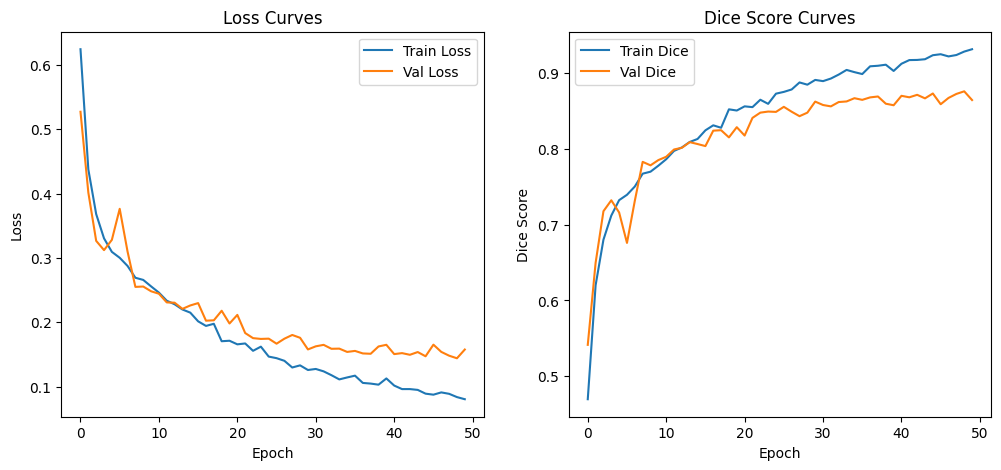

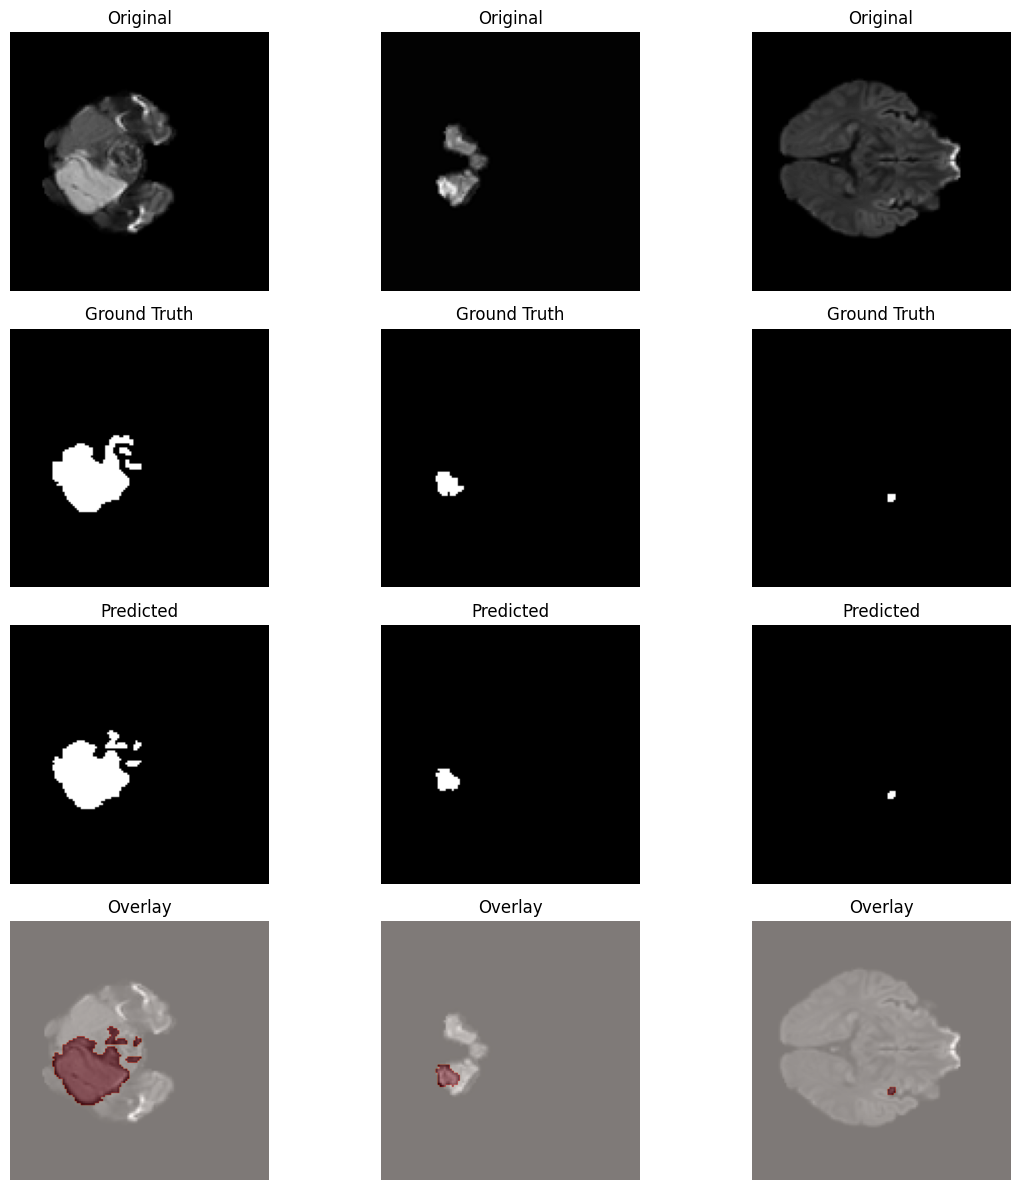

Average Dice on test batch: 0.8190846294164658
Test Metrics:
Average Dice: 0.8191
Average IoU: 0.7228
Precision: 0.9365, Recall: 0.8994, F1-score: 0.9176


In [2]:
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F



class StrokeDataset(Dataset):
    def __init__(self, image_files, mask_files, transform=None, target_size=(128,128)):
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("L")
        mask  = Image.open(self.mask_files[idx]).convert("L")

        # Resize
        image = image.resize(self.target_size)
        mask  = mask.resize(self.target_size)

        if self.transform:
            image = self.transform(image)
            mask  = self.transform(mask)

        mask = (mask > 0).float()  # binarize mask
        return image, mask




data_dir = '/kaggle/input/only-slices-with-stroke/'
cases = os.listdir(data_dir)

images, masks = [], []
for case in cases:
    case_path = os.path.join(data_dir, case)
    if os.path.isdir(case_path):
        dwi_files = sorted(glob(os.path.join(case_path, '*dwi*.png')))
        mask_files = sorted(glob(os.path.join(case_path, '*mask*.png')))
        images.extend(dwi_files)
        masks.extend(mask_files)

# Train/Val/Test split: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")



transform = transforms.ToTensor()

train_dataset = StrokeDataset(X_train, y_train, transform=transform, target_size=(128,128))
val_dataset   = StrokeDataset(X_val, y_val, transform=transform, target_size=(128,128))
test_dataset  = StrokeDataset(X_test, y_test, transform=transform, target_size=(128,128))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)



class UNet(nn.Module):
    def __init__(self, num_groups=8):
        super(UNet, self).__init__()

        def CGR(in_ch, out_ch):
            # Convolution + GroupNorm + ReLU
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.GroupNorm(num_groups=min(num_groups, out_ch), num_channels=out_ch),
                nn.ReLU(inplace=True)
            )

        self.enc1 = CGR(1, 64)
        self.enc2 = CGR(64, 128)
        self.enc3 = CGR(128, 256)
        self.enc4 = CGR(256, 512)

        self.pool = nn.MaxPool2d(2,2)
        self.center = CGR(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024,512,2,stride=2)
        self.dec4 = CGR(1024,512)
        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.dec3 = CGR(512,256)
        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.dec2 = CGR(256,128)
        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.dec1 = CGR(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        center = self.center(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(center), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.final(d1))


def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
    def forward(self, pred, target):
        return self.bce(pred, target) + dice_loss(pred, target)

def dice_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    return (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)


def iou_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(num_groups=8).to(device)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 50

train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0
    running_dice = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*imgs.size(0)
        running_dice += dice_score(outputs, masks).item()*imgs.size(0)

    train_loss = running_loss/len(train_loader.dataset)
    train_dice = running_dice/len(train_loader.dataset)
    train_losses.append(train_loss)
    train_dice_scores.append(train_dice)

    # Validation
    model.eval()
    val_loss, val_dice = 0,0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()*imgs.size(0)
            val_dice += dice_score(outputs, masks).item()*imgs.size(0)
    val_loss /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)
    val_losses.append(val_loss)
    val_dice_scores.append(val_dice)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")



plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves"); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_dice_scores, label='Train Dice')
plt.plot(val_dice_scores, label='Val Dice')
plt.xlabel("Epoch"); plt.ylabel("Dice Score"); plt.title("Dice Score Curves"); plt.legend()
plt.show()



model.eval()
with torch.no_grad():
    imgs, masks = next(iter(test_loader))
    imgs, masks = imgs.to(device), masks.to(device)
    preds = model(imgs)
    preds_bin = (preds>0.5).float()

# Move to CPU
imgs = imgs.cpu(); masks = masks.cpu(); preds_bin = preds_bin.cpu()

plt.figure(figsize=(12,12))
for i in range(3):
    plt.subplot(4,3,i+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray'); plt.title("Original"); plt.axis('off')
    plt.subplot(4,3,i+4)
    plt.imshow(masks[i].squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(4,3,i+7)
    plt.imshow(preds_bin[i].squeeze(), cmap='gray'); plt.title("Predicted"); plt.axis('off')
    plt.subplot(4,3,i+10)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.imshow(preds_bin[i].squeeze(), alpha=0.5, cmap='Reds'); plt.title("Overlay"); plt.axis('off')
plt.tight_layout()
plt.show()

# Average Dice score on test batch
dice_scores = [dice_score(preds_bin[i], masks[i]).item() for i in range(len(masks))]
print("Average Dice on test batch:", sum(dice_scores)/len(dice_scores))
iou_scores  = [iou_score(preds_bin[i], masks[i]).item() for i in range(len(masks))]

# Flatten for precision/recall/f1
pred_flat = preds_bin.view(-1).numpy()
mask_flat = masks.view(-1).numpy()

precision = precision_score(mask_flat, pred_flat)
recall = recall_score(mask_flat, pred_flat)
f1 = f1_score(mask_flat, pred_flat)

print(f"Test Metrics:\n"
      f"Average Dice: {sum(dice_scores)/len(dice_scores):.4f}\n"
      f"Average IoU: {sum(iou_scores)/len(iou_scores):.4f}\n"
      f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")


Train: 3378, Val: 724, Test: 725
Epoch [1/100] Train Loss: 0.6915, Train Dice: 0.4562 | Val Loss: 0.5240, Val Dice: 0.5469 | LR: 0.001000
Epoch [2/100] Train Loss: 0.4685, Train Dice: 0.5954 | Val Loss: 0.3919, Val Dice: 0.6598 | LR: 0.001000
Epoch [3/100] Train Loss: 0.3975, Train Dice: 0.6548 | Val Loss: 0.3988, Val Dice: 0.6539 | LR: 0.001000
Epoch [4/100] Train Loss: 0.3888, Train Dice: 0.6610 | Val Loss: 0.4069, Val Dice: 0.6562 | LR: 0.001000
Epoch [5/100] Train Loss: 0.3647, Train Dice: 0.6828 | Val Loss: 0.3340, Val Dice: 0.7082 | LR: 0.001000
Epoch [6/100] Train Loss: 0.3456, Train Dice: 0.6998 | Val Loss: 0.3300, Val Dice: 0.7142 | LR: 0.001000
Epoch [7/100] Train Loss: 0.3303, Train Dice: 0.7131 | Val Loss: 0.2993, Val Dice: 0.7425 | LR: 0.001000
Epoch [8/100] Train Loss: 0.3249, Train Dice: 0.7176 | Val Loss: 0.3055, Val Dice: 0.7364 | LR: 0.001000
Epoch [9/100] Train Loss: 0.3183, Train Dice: 0.7240 | Val Loss: 0.2910, Val Dice: 0.7485 | LR: 0.001000
Epoch [10/100] Train L

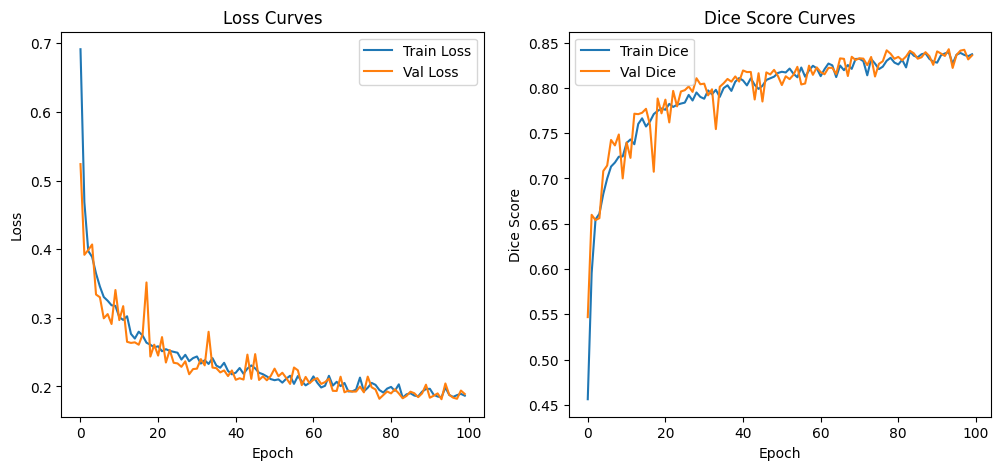

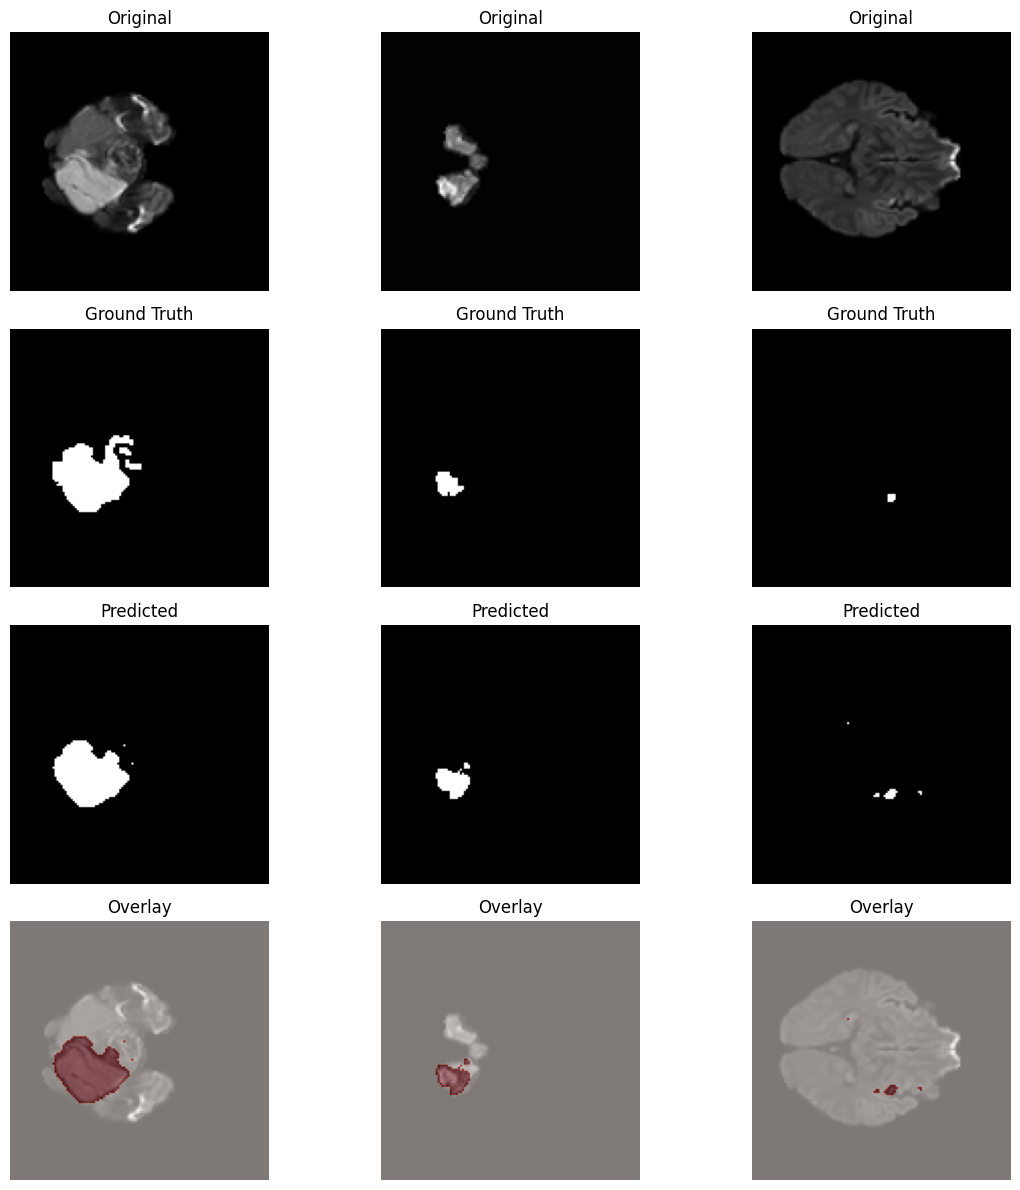

Average Dice on test batch: 0.7488310616463423


In [7]:
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn


# -----------------------------
# Dataset
# -----------------------------
class StrokeDataset(Dataset):
    def __init__(self, image_files, mask_files, transform=None, target_size=(128,128)):
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("L")
        mask  = Image.open(self.mask_files[idx]).convert("L")

        # Resize
        image = image.resize(self.target_size)
        mask  = mask.resize(self.target_size)

        # Apply same transform to both image and mask
        if self.transform:
            seed = np.random.randint(2147483647)
            torch.manual_seed(seed); image = self.transform(image)
            torch.manual_seed(seed); mask  = self.transform(mask)

        mask = (mask > 0).float()  # binarize mask
        return image, mask


# -----------------------------
# Model (UNet with Dropout)
# -----------------------------
class UNet(nn.Module):
    def __init__(self, num_groups=8, dropout=0.3):
        super(UNet, self).__init__()

        def CGR(in_ch, out_ch, use_dropout=False):
            layers = [
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.GroupNorm(num_groups=min(num_groups, out_ch), num_channels=out_ch),
                nn.ReLU(inplace=True),
            ]
            if use_dropout:
                layers.append(nn.Dropout(dropout))
            return nn.Sequential(*layers)

        self.enc1 = CGR(1, 64)
        self.enc2 = CGR(64, 128)
        self.enc3 = CGR(128, 256)
        self.enc4 = CGR(256, 512)

        self.pool = nn.MaxPool2d(2,2)
        self.center = CGR(512, 1024, use_dropout=True)

        self.up4 = nn.ConvTranspose2d(1024,512,2,stride=2)
        self.dec4 = CGR(1024,512, use_dropout=True)
        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.dec3 = CGR(512,256, use_dropout=True)
        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.dec2 = CGR(256,128)
        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.dec1 = CGR(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        center = self.center(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(center), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.final(d1))


# -----------------------------
# Loss + Metrics
# -----------------------------
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
    def forward(self, pred, target):
        return self.bce(pred, target) + dice_loss(pred, target)

def dice_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    return (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)


# -----------------------------
# EarlyStopping
# -----------------------------
class EarlyStopping:
    def __init__(self, patience=7, delta=0, path="best_model.pth"):
        self.patience = patience
        self.delta = delta
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False
        self.path = path

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


# -----------------------------
# Data
# -----------------------------
data_dir = '/kaggle/input/only-slices-with-stroke/'
cases = os.listdir(data_dir)

images, masks = [], []
for case in cases:
    case_path = os.path.join(data_dir, case)
    if os.path.isdir(case_path):
        dwi_files = sorted(glob(os.path.join(case_path, '*dwi*.png')))
        mask_files = sorted(glob(os.path.join(case_path, '*mask*.png')))
        images.extend(dwi_files)
        masks.extend(mask_files)

# Train/Val/Test split
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Augmentations (only for training)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

val_test_transform = transforms.ToTensor()

train_dataset = StrokeDataset(X_train, y_train, transform=train_transform, target_size=(128,128))
val_dataset   = StrokeDataset(X_val, y_val, transform=val_test_transform, target_size=(128,128))
test_dataset  = StrokeDataset(X_test, y_test, transform=val_test_transform, target_size=(128,128))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)


# -----------------------------
# Training
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(num_groups=8).to(device)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
early_stopping = EarlyStopping(patience=20, path="best_unet.pth")

num_epochs = 100
train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss, running_dice = 0, 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*imgs.size(0)
        running_dice += dice_score(outputs, masks).item()*imgs.size(0)

    train_loss = running_loss/len(train_loader.dataset)
    train_dice = running_dice/len(train_loader.dataset)
    train_losses.append(train_loss)
    train_dice_scores.append(train_dice)

    # Validation
    model.eval()
    val_loss, val_dice = 0,0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()*imgs.size(0)
            val_dice += dice_score(outputs, masks).item()*imgs.size(0)
    val_loss /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)
    val_losses.append(val_loss)
    val_dice_scores.append(val_dice)

    # Scheduler + EarlyStopping
    scheduler.step(val_loss)
    early_stopping(val_loss, model)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

# Load best model
model.load_state_dict(torch.load("best_unet.pth"))


# -----------------------------
# Plot Curves
# -----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves"); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_dice_scores, label='Train Dice')
plt.plot(val_dice_scores, label='Val Dice')
plt.xlabel("Epoch"); plt.ylabel("Dice Score"); plt.title("Dice Score Curves"); plt.legend()
plt.show()


# -----------------------------
# Test Visualization
# -----------------------------
model.eval()
with torch.no_grad():
    imgs, masks = next(iter(test_loader))
    imgs, masks = imgs.to(device), masks.to(device)
    preds = model(imgs)
    preds_bin = (preds>0.5).float()

imgs = imgs.cpu(); masks = masks.cpu(); preds_bin = preds_bin.cpu()

plt.figure(figsize=(12,12))
for i in range(3):
    plt.subplot(4,3,i+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray'); plt.title("Original"); plt.axis('off')
    plt.subplot(4,3,i+4)
    plt.imshow(masks[i].squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(4,3,i+7)
    plt.imshow(preds_bin[i].squeeze(), cmap='gray'); plt.title("Predicted"); plt.axis('off')
    plt.subplot(4,3,i+10)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.imshow(preds_bin[i].squeeze(), alpha=0.5, cmap='Reds'); plt.title("Overlay"); plt.axis('off')
plt.tight_layout()
plt.show()

# Average Dice score on test batch
dice_scores = [dice_score(preds_bin[i], masks[i]).item() for i in range(len(masks))]
print("Average Dice on test batch:", sum(dice_scores)/len(dice_scores))


Train: 3378, Val: 724, Test: 725
Epoch [1/50] Train Loss: 0.5804, Train Dice: 0.5242 | Val Loss: 0.4205, Val Dice: 0.6491
Epoch [2/50] Train Loss: 0.3748, Train Dice: 0.6766 | Val Loss: 0.3240, Val Dice: 0.7195
Epoch [3/50] Train Loss: 0.3443, Train Dice: 0.7022 | Val Loss: 0.3690, Val Dice: 0.6777
Epoch [4/50] Train Loss: 0.3141, Train Dice: 0.7286 | Val Loss: 0.2992, Val Dice: 0.7446
Epoch [5/50] Train Loss: 0.3031, Train Dice: 0.7382 | Val Loss: 0.2748, Val Dice: 0.7642
Epoch [6/50] Train Loss: 0.2909, Train Dice: 0.7477 | Val Loss: 0.2855, Val Dice: 0.7503
Epoch [7/50] Train Loss: 0.2798, Train Dice: 0.7570 | Val Loss: 0.2567, Val Dice: 0.7774
Epoch [8/50] Train Loss: 0.2582, Train Dice: 0.7765 | Val Loss: 0.2524, Val Dice: 0.7810
Epoch [9/50] Train Loss: 0.2591, Train Dice: 0.7756 | Val Loss: 0.2524, Val Dice: 0.7810
Epoch [10/50] Train Loss: 0.2485, Train Dice: 0.7851 | Val Loss: 0.2434, Val Dice: 0.7885
Epoch [11/50] Train Loss: 0.2348, Train Dice: 0.7972 | Val Loss: 0.2425, Val

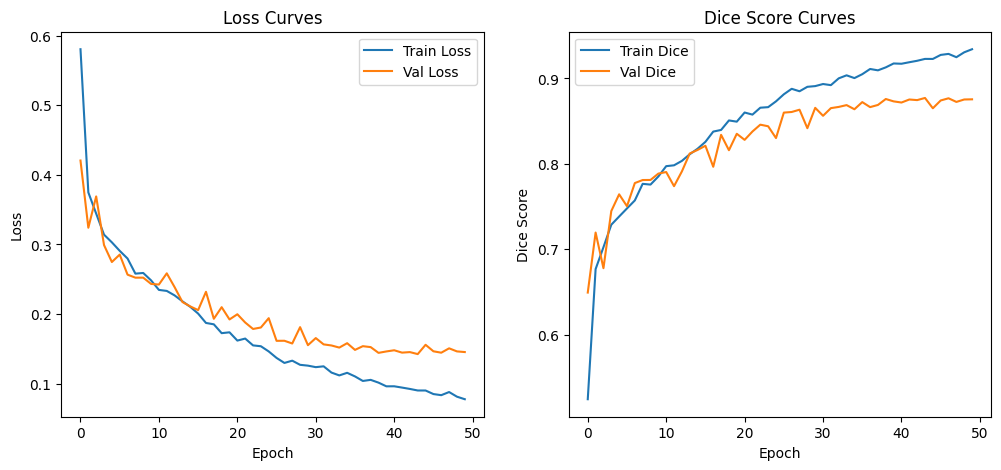

Test Metrics:
Average Dice: 0.7544
Average IoU: 0.6624
Precision: 0.8953, Recall: 0.8992, F1-score: 0.8972


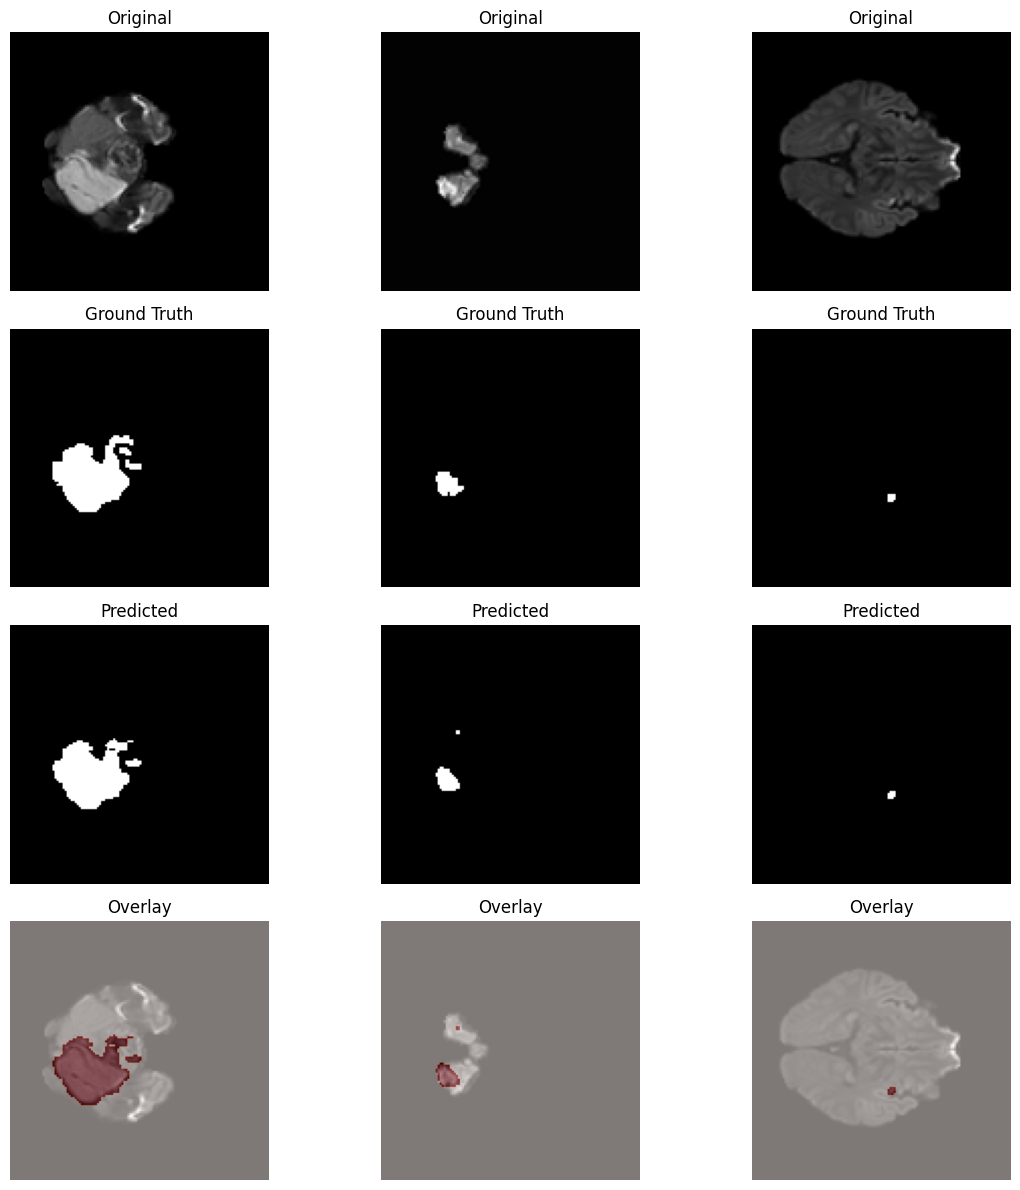

In [8]:
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score


# ----------------------------
# Dataset
# ----------------------------
class StrokeDataset(Dataset):
    def __init__(self, image_files, mask_files, transform=None, target_size=(128,128)):
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("L")
        mask  = Image.open(self.mask_files[idx]).convert("L")

        # Resize
        image = image.resize(self.target_size)
        mask  = mask.resize(self.target_size)

        if self.transform:
            image = self.transform(image)
            mask  = self.transform(mask)

        mask = (mask > 0).float()  # binarize mask
        return image, mask


# ----------------------------
# Data loading
# ----------------------------
data_dir = '/kaggle/input/only-slices-with-stroke/'
cases = os.listdir(data_dir)

images, masks = [], []
for case in cases:
    case_path = os.path.join(data_dir, case)
    if os.path.isdir(case_path):
        dwi_files = sorted(glob(os.path.join(case_path, '*dwi*.png')))
        mask_files = sorted(glob(os.path.join(case_path, '*mask*.png')))
        images.extend(dwi_files)
        masks.extend(mask_files)

# Train/Val/Test split: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

transform = transforms.ToTensor()

train_dataset = StrokeDataset(X_train, y_train, transform=transform, target_size=(128,128))
val_dataset   = StrokeDataset(X_val, y_val, transform=transform, target_size=(128,128))
test_dataset  = StrokeDataset(X_test, y_test, transform=transform, target_size=(128,128))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)


# ----------------------------
# UNet Model
# ----------------------------
class UNet(nn.Module):
    def __init__(self, num_groups=8):
        super(UNet, self).__init__()

        def CGR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.GroupNorm(num_groups=min(num_groups, out_ch), num_channels=out_ch),
                nn.ReLU(inplace=True)
            )

        self.enc1 = CGR(1, 64)
        self.enc2 = CGR(64, 128)
        self.enc3 = CGR(128, 256)
        self.enc4 = CGR(256, 512)

        self.pool = nn.MaxPool2d(2,2)
        self.center = CGR(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024,512,2,stride=2)
        self.dec4 = CGR(1024,512)
        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.dec3 = CGR(512,256)
        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.dec2 = CGR(256,128)
        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.dec1 = CGR(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        center = self.center(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(center), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.final(d1))


# ----------------------------
# Loss & Metrics
# ----------------------------
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
    def forward(self, pred, target):
        return self.bce(pred, target) + dice_loss(pred, target)

def dice_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    return (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)


# ----------------------------
# Training
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(num_groups=8).to(device)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 50

train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, running_dice = 0,0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*imgs.size(0)
        running_dice += dice_score(outputs, masks).item()*imgs.size(0)
    train_loss = running_loss/len(train_loader.dataset)
    train_dice = running_dice/len(train_loader.dataset)
    train_losses.append(train_loss)
    train_dice_scores.append(train_dice)

    # Validation
    model.eval()
    val_loss, val_dice = 0,0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()*imgs.size(0)
            val_dice += dice_score(outputs, masks).item()*imgs.size(0)
    val_loss /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)
    val_losses.append(val_loss)
    val_dice_scores.append(val_dice)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")


# ----------------------------
# Plot Training Curves
# ----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves"); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_dice_scores, label='Train Dice')
plt.plot(val_dice_scores, label='Val Dice')
plt.xlabel("Epoch"); plt.ylabel("Dice Score"); plt.title("Dice Score Curves"); plt.legend()
plt.show()


# ----------------------------
# Test Evaluation (All Metrics)
# ----------------------------
model.eval()
all_preds, all_masks = [], []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds_bin = (outputs>0.5).float()
        all_preds.append(preds_bin.cpu())
        all_masks.append(masks.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_masks = torch.cat(all_masks, dim=0)

# Dice, IoU
dice_scores = [dice_score(all_preds[i], all_masks[i]).item() for i in range(len(all_masks))]
iou_scores  = [iou_score(all_preds[i], all_masks[i]).item() for i in range(len(all_masks))]

# Flatten for precision/recall/f1
pred_flat = all_preds.view(-1).numpy()
mask_flat = all_masks.view(-1).numpy()

precision = precision_score(mask_flat, pred_flat)
recall = recall_score(mask_flat, pred_flat)
f1 = f1_score(mask_flat, pred_flat)

print(f"Test Metrics:\n"
      f"Average Dice: {sum(dice_scores)/len(dice_scores):.4f}\n"
      f"Average IoU: {sum(iou_scores)/len(iou_scores):.4f}\n"
      f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")


# ----------------------------
# Visualize Test Results
# ----------------------------
plt.figure(figsize=(12,12))
for i in range(min(3, len(all_preds))):
    plt.subplot(4,3,i+1)
    plt.imshow(test_dataset[i][0].squeeze(), cmap='gray'); plt.title("Original"); plt.axis('off')
    plt.subplot(4,3,i+4)
    plt.imshow(test_dataset[i][1].squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(4,3,i+7)
    plt.imshow(all_preds[i].squeeze(), cmap='gray'); plt.title("Predicted"); plt.axis('off')
    plt.subplot(4,3,i+10)
    plt.imshow(test_dataset[i][0].squeeze(), cmap='gray')
    plt.imshow(all_preds[i].squeeze(), alpha=0.5, cmap='Reds'); plt.title("Overlay"); plt.axis('off')
plt.tight_layout()
plt.show()


Train: 3378, Val: 724, Test: 725
Epoch [1/50] Train Loss: 0.5779, Train Dice: 0.5308 | Val Loss: 0.6482, Val Dice: 0.4276
Epoch [2/50] Train Loss: 0.4170, Train Dice: 0.6373 | Val Loss: 0.3812, Val Dice: 0.6708
Epoch [3/50] Train Loss: 0.3667, Train Dice: 0.6812 | Val Loss: 0.4818, Val Dice: 0.5857
Epoch [4/50] Train Loss: 0.3325, Train Dice: 0.7106 | Val Loss: 0.3007, Val Dice: 0.7381
Epoch [5/50] Train Loss: 0.3124, Train Dice: 0.7284 | Val Loss: 0.2943, Val Dice: 0.7481
Epoch [6/50] Train Loss: 0.2917, Train Dice: 0.7465 | Val Loss: 0.3081, Val Dice: 0.7382
Epoch [7/50] Train Loss: 0.2864, Train Dice: 0.7503 | Val Loss: 0.2862, Val Dice: 0.7497
Epoch [8/50] Train Loss: 0.2788, Train Dice: 0.7568 | Val Loss: 0.2702, Val Dice: 0.7645
Epoch [9/50] Train Loss: 0.2685, Train Dice: 0.7661 | Val Loss: 0.2726, Val Dice: 0.7643
Epoch [10/50] Train Loss: 0.2605, Train Dice: 0.7729 | Val Loss: 0.2463, Val Dice: 0.7860
Epoch [11/50] Train Loss: 0.2532, Train Dice: 0.7795 | Val Loss: 0.2859, Val

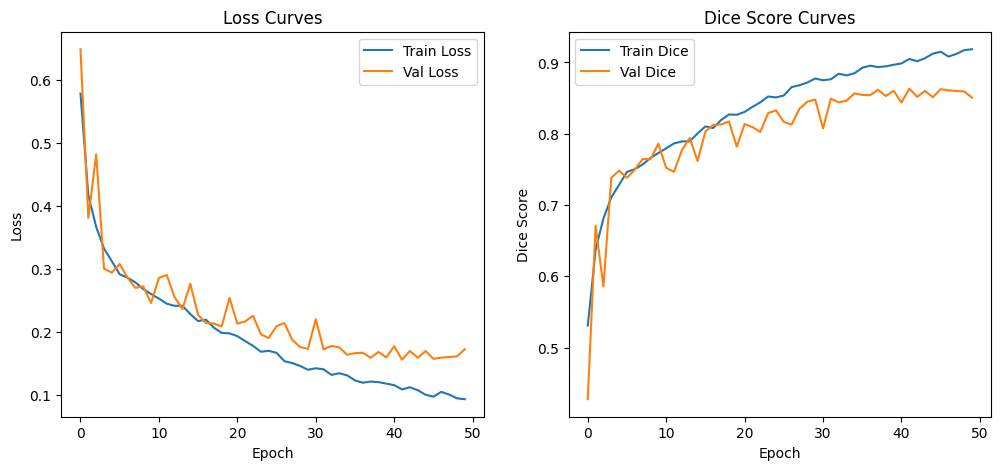

Test Metrics:
Average Dice: 0.7182
Average IoU: 0.6211
Precision: 0.8372, Recall: 0.9156, F1-score: 0.8746


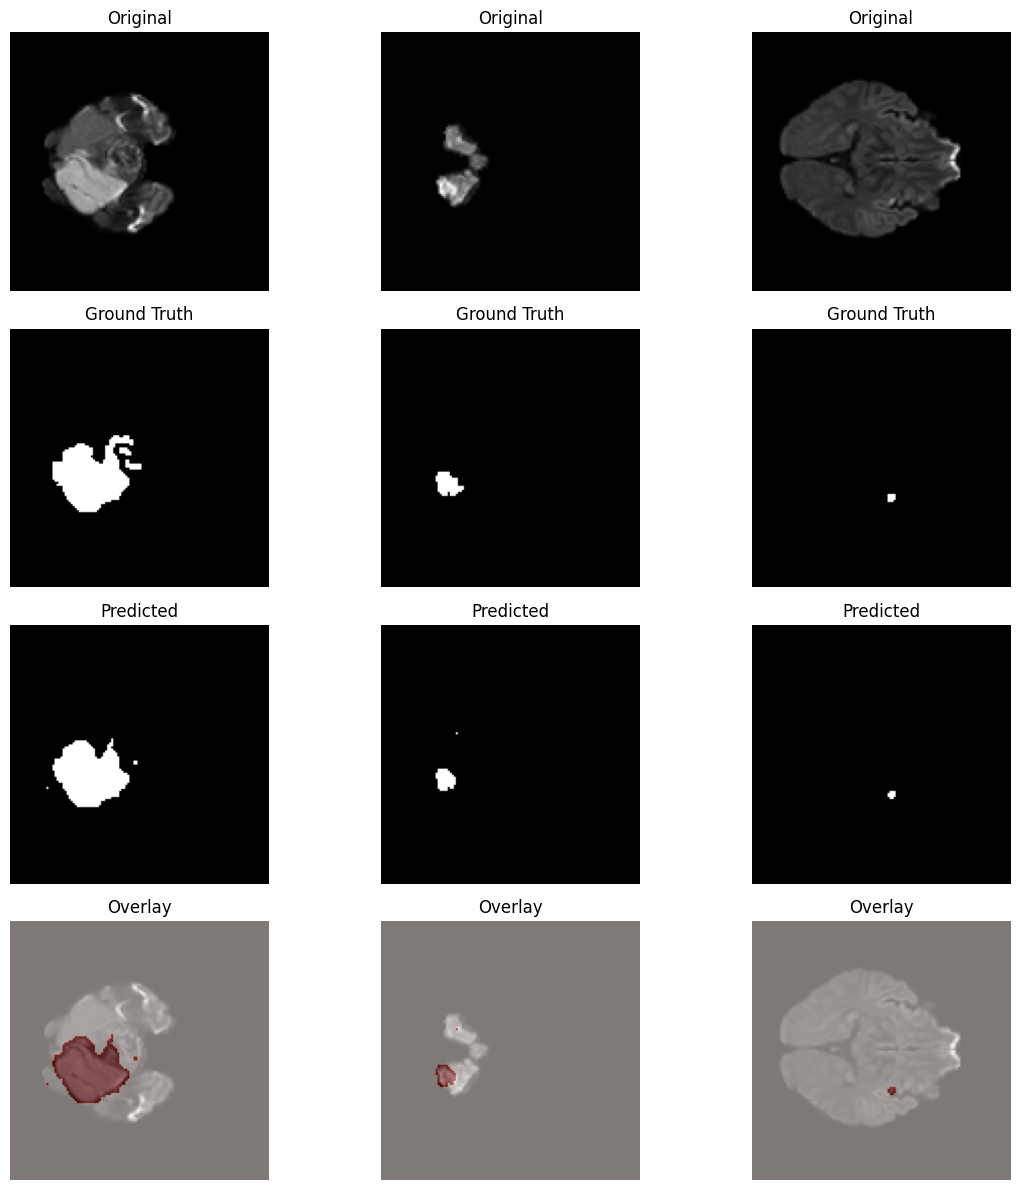

In [9]:
## Attention unet
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F


# ----------------------------
# Dataset
# ----------------------------
class StrokeDataset(Dataset):
    def __init__(self, image_files, mask_files, transform=None, target_size=(128,128)):
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("L")
        mask  = Image.open(self.mask_files[idx]).convert("L")

        image = image.resize(self.target_size)
        mask  = mask.resize(self.target_size)

        if self.transform:
            image = self.transform(image)
            mask  = self.transform(mask)

        mask = (mask > 0).float()
        return image, mask


# ----------------------------
# Data loading
# ----------------------------
data_dir = '/kaggle/input/only-slices-with-stroke/'
cases = os.listdir(data_dir)

images, masks = [], []
for case in cases:
    case_path = os.path.join(data_dir, case)
    if os.path.isdir(case_path):
        dwi_files = sorted(glob(os.path.join(case_path, '*dwi*.png')))
        mask_files = sorted(glob(os.path.join(case_path, '*mask*.png')))
        images.extend(dwi_files)
        masks.extend(mask_files)

# Train/Val/Test split: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

transform = transforms.ToTensor()

train_dataset = StrokeDataset(X_train, y_train, transform=transform, target_size=(128,128))
val_dataset   = StrokeDataset(X_val, y_val, transform=transform, target_size=(128,128))
test_dataset  = StrokeDataset(X_test, y_test, transform=transform, target_size=(128,128))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)


# ----------------------------
# Attention Block
# ----------------------------
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


# ----------------------------
# Attention U-Net Model
# ----------------------------
class AttentionUNet(nn.Module):
    def __init__(self, num_groups=8):
        super().__init__()

        def CGR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.GroupNorm(num_groups=min(num_groups, out_ch), num_channels=out_ch),
                nn.ReLU(inplace=True)
            )

        self.enc1 = CGR(1, 64)
        self.enc2 = CGR(64, 128)
        self.enc3 = CGR(128, 256)
        self.enc4 = CGR(256, 512)

        self.pool = nn.MaxPool2d(2, 2)
        self.center = CGR(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att4 = AttentionBlock(F_g=512, F_l=512, F_int=256)
        self.dec4 = CGR(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att3 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.dec3 = CGR(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att2 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.dec2 = CGR(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec1 = CGR(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        center = self.center(self.pool(e4))

        d4 = self.up4(center)
        e4 = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        out = torch.sigmoid(self.final(d1))
        return out


# ----------------------------
# Loss & Metrics
# ----------------------------
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
    def forward(self, pred, target):
        return self.bce(pred, target) + dice_loss(pred, target)

def dice_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    return (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)


# ----------------------------
# Training Loop
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttentionUNet(num_groups=8).to(device)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 50

train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, running_dice = 0, 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*imgs.size(0)
        running_dice += dice_score(outputs, masks).item()*imgs.size(0)

    train_loss = running_loss/len(train_loader.dataset)
    train_dice = running_dice/len(train_loader.dataset)
    train_losses.append(train_loss)
    train_dice_scores.append(train_dice)

    # Validation
    model.eval()
    val_loss, val_dice = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()*imgs.size(0)
            val_dice += dice_score(outputs, masks).item()*imgs.size(0)

    val_loss /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)
    val_losses.append(val_loss)
    val_dice_scores.append(val_dice)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")


# ----------------------------
# Plot Training Curves
# ----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves"); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_dice_scores, label='Train Dice')
plt.plot(val_dice_scores, label='Val Dice')
plt.xlabel("Epoch"); plt.ylabel("Dice Score"); plt.title("Dice Score Curves"); plt.legend()
plt.show()


# ----------------------------
# Test Evaluation
# ----------------------------
model.eval()
all_preds, all_masks = [], []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds_bin = (outputs>0.5).float()
        all_preds.append(preds_bin.cpu())
        all_masks.append(masks.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_masks = torch.cat(all_masks, dim=0)

# Dice, IoU
dice_scores = [dice_score(all_preds[i], all_masks[i]).item() for i in range(len(all_masks))]
iou_scores  = [iou_score(all_preds[i], all_masks[i]).item() for i in range(len(all_masks))]

# Flatten for precision/recall/f1
pred_flat = all_preds.view(-1).numpy()
mask_flat = all_masks.view(-1).numpy()

precision = precision_score(mask_flat, pred_flat)
recall = recall_score(mask_flat, pred_flat)
f1 = f1_score(mask_flat, pred_flat)

print(f"Test Metrics:\n"
      f"Average Dice: {sum(dice_scores)/len(dice_scores):.4f}\n"
      f"Average IoU: {sum(iou_scores)/len(iou_scores):.4f}\n"
      f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")


# ----------------------------
# Visualize Test Results
# ----------------------------
plt.figure(figsize=(12,12))
for i in range(min(3, len(all_preds))):
    plt.subplot(4,3,i+1)
    plt.imshow(test_dataset[i][0].squeeze(), cmap='gray'); plt.title("Original"); plt.axis('off')
    plt.subplot(4,3,i+4)
    plt.imshow(test_dataset[i][1].squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(4,3,i+7)
    plt.imshow(all_preds[i].squeeze(), cmap='gray'); plt.title("Predicted"); plt.axis('off')
    plt.subplot(4,3,i+10)
    plt.imshow(test_dataset[i][0].squeeze(), cmap='gray')
    plt.imshow(all_preds[i].squeeze(), alpha=0.5, cmap='Reds'); plt.title("Overlay"); plt.axis('off')
plt.tight_layout()
plt.show()


Train: 3378, Val: 724, Test: 725
Epoch [1/50] Train Loss: 0.6372, Train Dice: 0.4577 | Val Loss: 0.4551, Val Dice: 0.6082
Epoch [2/50] Train Loss: 0.4380, Train Dice: 0.6241 | Val Loss: 0.4227, Val Dice: 0.6396
Epoch [3/50] Train Loss: 0.3886, Train Dice: 0.6638 | Val Loss: 0.3914, Val Dice: 0.6536
Epoch [4/50] Train Loss: 0.3613, Train Dice: 0.6891 | Val Loss: 0.7641, Val Dice: 0.4752
Epoch [5/50] Train Loss: 0.3290, Train Dice: 0.7159 | Val Loss: 0.2874, Val Dice: 0.7493
Epoch [6/50] Train Loss: 0.3001, Train Dice: 0.7408 | Val Loss: 0.2846, Val Dice: 0.7534
Epoch [7/50] Train Loss: 0.3029, Train Dice: 0.7394 | Val Loss: 0.2802, Val Dice: 0.7572
Epoch [8/50] Train Loss: 0.2864, Train Dice: 0.7527 | Val Loss: 0.2905, Val Dice: 0.7475
Epoch [9/50] Train Loss: 0.2729, Train Dice: 0.7639 | Val Loss: 0.3450, Val Dice: 0.6993
Epoch [10/50] Train Loss: 0.2678, Train Dice: 0.7704 | Val Loss: 0.3033, Val Dice: 0.7345
Epoch [11/50] Train Loss: 0.2585, Train Dice: 0.7786 | Val Loss: 0.2439, Val

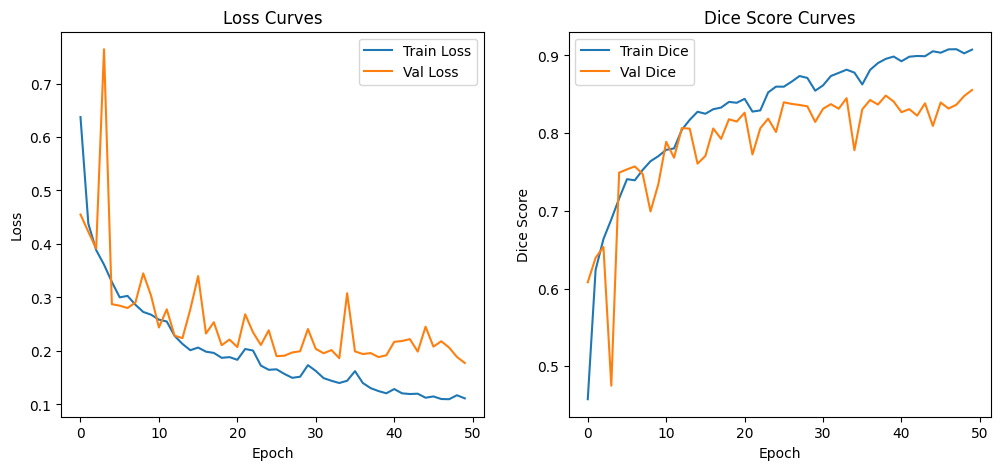

Test Metrics:
Average Dice: 0.7009
Average IoU: 0.6127
Precision: 0.9027, Recall: 0.8716, F1-score: 0.8869


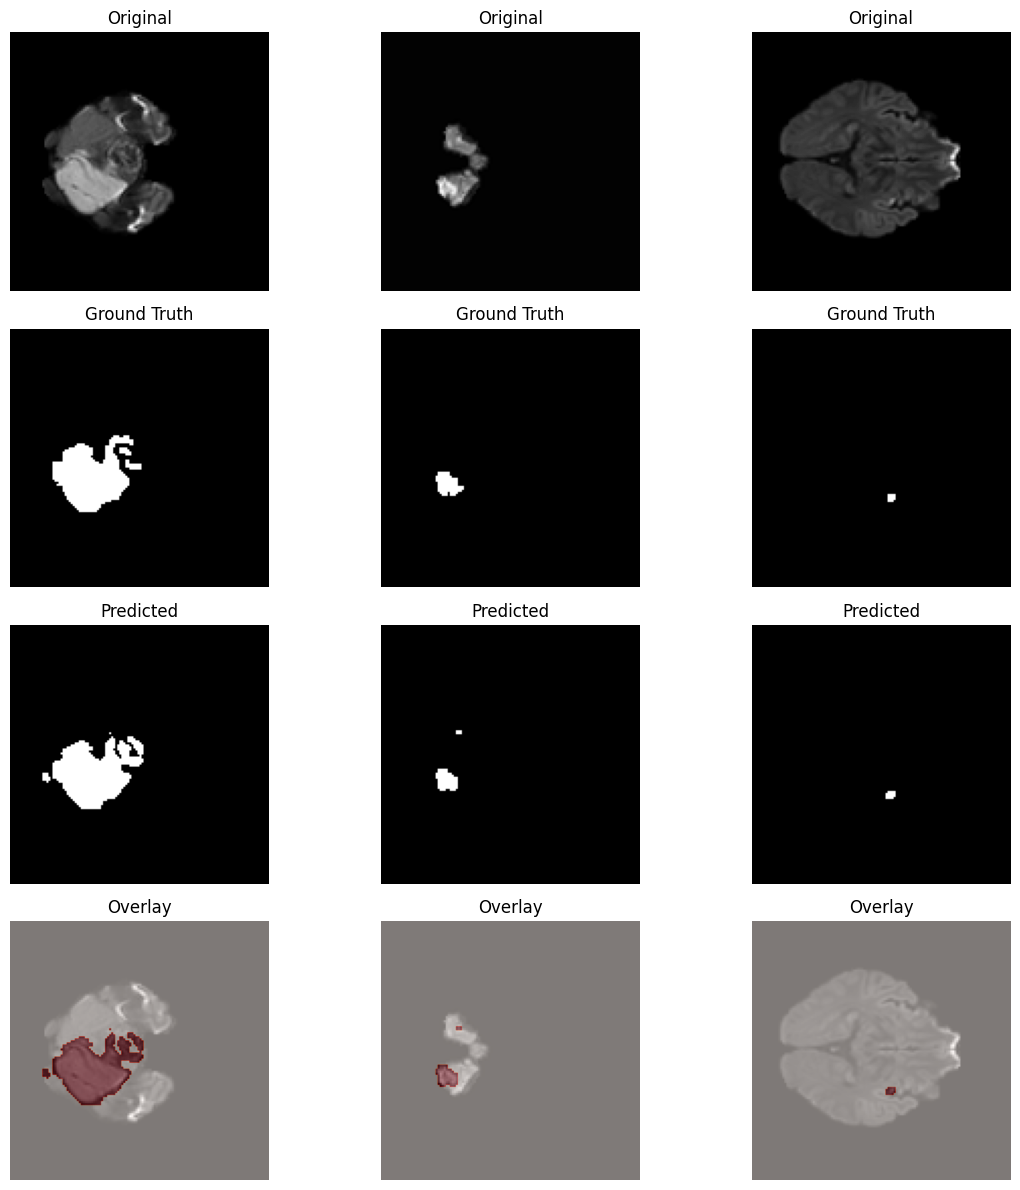

In [17]:
# Resnet + attention unet decoder
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from sklearn.metrics import precision_score, recall_score, f1_score

# ----------------------------
# Dataset
# ----------------------------
class StrokeDataset(Dataset):
    def __init__(self, image_files, mask_files, transform=None, target_size=(128,128)):
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("L")
        mask  = Image.open(self.mask_files[idx]).convert("L")

        # Resize
        image = image.resize(self.target_size)
        mask  = mask.resize(self.target_size)

        if self.transform:
            image = self.transform(image)
            mask  = self.transform(mask)

        mask = (mask > 0).float()  # binarize mask
        return image, mask

# ----------------------------
# Data loading
# ----------------------------
data_dir = '/kaggle/input/only-slices-with-stroke/'
cases = os.listdir(data_dir)

images, masks = [], []
for case in cases:
    case_path = os.path.join(data_dir, case)
    if os.path.isdir(case_path):
        dwi_files = sorted(glob(os.path.join(case_path, '*dwi*.png')))
        mask_files = sorted(glob(os.path.join(case_path, '*mask*.png')))
        images.extend(dwi_files)
        masks.extend(mask_files)

# Train/Val/Test split: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

transform = transforms.ToTensor()

train_dataset = StrokeDataset(X_train, y_train, transform=transform, target_size=(128,128))
val_dataset   = StrokeDataset(X_val, y_val, transform=transform, target_size=(128,128))
test_dataset  = StrokeDataset(X_test, y_test, transform=transform, target_size=(128,128))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)

# ----------------------------
# Attention Block
# ----------------------------
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True)
        self.W_x = nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True)
        self.psi = nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()
    def forward(self, g, x):
        # g: gating signal (decoder), x: skip connection (encoder)
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        # interpolate if needed
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)
        psi = self.relu(g1 + x1)
        psi = self.sigmoid(self.psi(psi))
        return x * psi

# ----------------------------
# ResNet Encoder + Attention U-Net Decoder
# ----------------------------
class ResNetAttentionUNet(nn.Module):
    def __init__(self, n_classes=1, pretrained=True):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT if pretrained else None)

        # Modify first conv for 1 channel
        self.encoder0 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            resnet.bn1,
            resnet.relu
        )
        self.pool0 = resnet.maxpool
        self.encoder1 = resnet.layer1  # 64
        self.encoder2 = resnet.layer2  # 128
        self.encoder3 = resnet.layer3  # 256
        self.encoder4 = resnet.layer4  # 512

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.dec4 = nn.Sequential(nn.Conv2d(512,256,3,padding=1), nn.ReLU(inplace=True))

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.dec3 = nn.Sequential(nn.Conv2d(256,128,3,padding=1), nn.ReLU(inplace=True))

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec2 = nn.Sequential(nn.Conv2d(128,64,3,padding=1), nn.ReLU(inplace=True))

        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec1 = nn.Sequential(nn.Conv2d(128,64,3,padding=1), nn.ReLU(inplace=True))

        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        # Encoder
        e0 = self.encoder0(x)
        e1 = self.encoder1(self.pool0(e0))
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)
    
        # Decoder + Attention
        d4 = self.up4(e4)
        e3_att = self.att4(g=d4, x=e3)
        if d4.shape[2:] != e3_att.shape[2:]:
            e3_att = F.interpolate(e3_att, size=d4.shape[2:], mode='bilinear', align_corners=True)
        d4 = self.dec4(torch.cat([d4, e3_att], dim=1))
    
        d3 = self.up3(d4)
        e2_att = self.att3(g=d3, x=e2)
        if d3.shape[2:] != e2_att.shape[2:]:
            e2_att = F.interpolate(e2_att, size=d3.shape[2:], mode='bilinear', align_corners=True)
        d3 = self.dec3(torch.cat([d3, e2_att], dim=1))
    
        d2 = self.up2(d3)
        e1_att = self.att2(g=d2, x=e1)
        if d2.shape[2:] != e1_att.shape[2:]:
            e1_att = F.interpolate(e1_att, size=d2.shape[2:], mode='bilinear', align_corners=True)
        d2 = self.dec2(torch.cat([d2, e1_att], dim=1))
    
        d1 = self.up1(d2)
        e0_att = self.att1(g=d1, x=e0)
        if d1.shape[2:] != e0_att.shape[2:]:
            e0_att = F.interpolate(e0_att, size=d1.shape[2:], mode='bilinear', align_corners=True)
        d1 = self.dec1(torch.cat([d1, e0_att], dim=1))
    
        out = self.final(d1)
    
        # --- Ensure output matches input size ---
        if out.shape[2:] != x.shape[2:]:
            out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=True)
    
        return torch.sigmoid(out)

# ----------------------------
# Loss & Metrics
# ----------------------------
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
    def forward(self, pred, target):
        return self.bce(pred, target) + dice_loss(pred, target)

def dice_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    return (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# ----------------------------
# Training
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetAttentionUNet(n_classes=1, pretrained=True).to(device)
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 50

train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, running_dice = 0,0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*imgs.size(0)
        running_dice += dice_score(outputs, masks).item()*imgs.size(0)
    train_loss = running_loss/len(train_loader.dataset)
    train_dice = running_dice/len(train_loader.dataset)
    train_losses.append(train_loss)
    train_dice_scores.append(train_dice)

    # Validation
    model.eval()
    val_loss, val_dice = 0,0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()*imgs.size(0)
            val_dice += dice_score(outputs, masks).item()*imgs.size(0)
    val_loss /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)
    val_losses.append(val_loss)
    val_dice_scores.append(val_dice)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")

# ----------------------------
# Plot Training Curves
# ----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves"); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_dice_scores, label='Train Dice')
plt.plot(val_dice_scores, label='Val Dice')
plt.xlabel("Epoch"); plt.ylabel("Dice Score"); plt.title("Dice Score Curves"); plt.legend()
plt.show()

# ----------------------------
# Test Evaluation (All Metrics)
# ----------------------------
model.eval()
all_preds, all_masks = [], []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds_bin = (outputs>0.5).float()
        all_preds.append(preds_bin.cpu())
        all_masks.append(masks.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_masks = torch.cat(all_masks, dim=0)

# Dice, IoU
dice_scores = [dice_score(all_preds[i], all_masks[i]).item() for i in range(len(all_masks))]
iou_scores  = [iou_score(all_preds[i], all_masks[i]).item() for i in range(len(all_masks))]

# Flatten for precision/recall/f1
pred_flat = all_preds.view(-1).numpy()
mask_flat = all_masks.view(-1).numpy()

precision = precision_score(mask_flat, pred_flat)
recall = recall_score(mask_flat, pred_flat)
f1 = f1_score(mask_flat, pred_flat)

print(f"Test Metrics:\n"
      f"Average Dice: {sum(dice_scores)/len(dice_scores):.4f}\n"
      f"Average IoU: {sum(iou_scores)/len(iou_scores):.4f}\n"
      f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

# ----------------------------
# Visualize Test Results
# ----------------------------
plt.figure(figsize=(12,12))
for i in range(min(3, len(all_preds))):
    plt.subplot(4,3,i+1)
    plt.imshow(test_dataset[i][0].squeeze(), cmap='gray'); plt.title("Original"); plt.axis('off')
    plt.subplot(4,3,i+4)
    plt.imshow(test_dataset[i][1].squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(4,3,i+7)
    plt.imshow(all_preds[i].squeeze(), cmap='gray'); plt.title("Predicted"); plt.axis('off')
    plt.subplot(4,3,i+10)
    plt.imshow(test_dataset[i][0].squeeze(), cmap='gray')
    plt.imshow(all_preds[i].squeeze(), alpha=0.5, cmap='Reds'); plt.title("Overlay"); plt.axis('off')
plt.tight_layout()
plt.show()


Train: 3378, Val: 724, Test: 725


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:02<00:00, 78.7MB/s] 


Epoch [1/50] Train Loss: 0.6638, Train Dice: 0.4479 | Val Loss: 0.5057, Val Dice: 0.5681
Epoch [2/50] Train Loss: 0.4786, Train Dice: 0.5881 | Val Loss: 0.4564, Val Dice: 0.6060
Epoch [3/50] Train Loss: 0.4438, Train Dice: 0.6171 | Val Loss: 0.3921, Val Dice: 0.6629
Epoch [4/50] Train Loss: 0.4076, Train Dice: 0.6496 | Val Loss: 0.4624, Val Dice: 0.6094
Epoch [5/50] Train Loss: 0.3929, Train Dice: 0.6625 | Val Loss: 0.4206, Val Dice: 0.6416
Epoch [6/50] Train Loss: 0.3840, Train Dice: 0.6700 | Val Loss: 0.3578, Val Dice: 0.6959
Epoch [7/50] Train Loss: 0.3638, Train Dice: 0.6877 | Val Loss: 0.3664, Val Dice: 0.6848
Epoch [8/50] Train Loss: 0.3515, Train Dice: 0.7001 | Val Loss: 0.3491, Val Dice: 0.6999
Epoch [9/50] Train Loss: 0.3430, Train Dice: 0.7069 | Val Loss: 0.3299, Val Dice: 0.7172
Epoch [10/50] Train Loss: 0.3235, Train Dice: 0.7245 | Val Loss: 0.3101, Val Dice: 0.7352
Epoch [11/50] Train Loss: 0.3147, Train Dice: 0.7326 | Val Loss: 0.3274, Val Dice: 0.7237
Epoch [12/50] Train

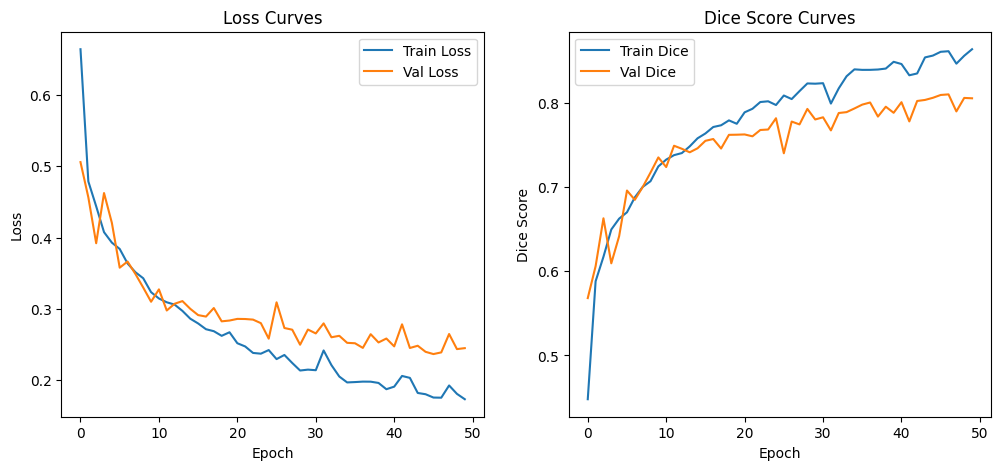

Test Metrics:
Average Dice: 0.6150
Average IoU: 0.5144
Precision: 0.8543, Recall: 0.8294, F1-score: 0.8417


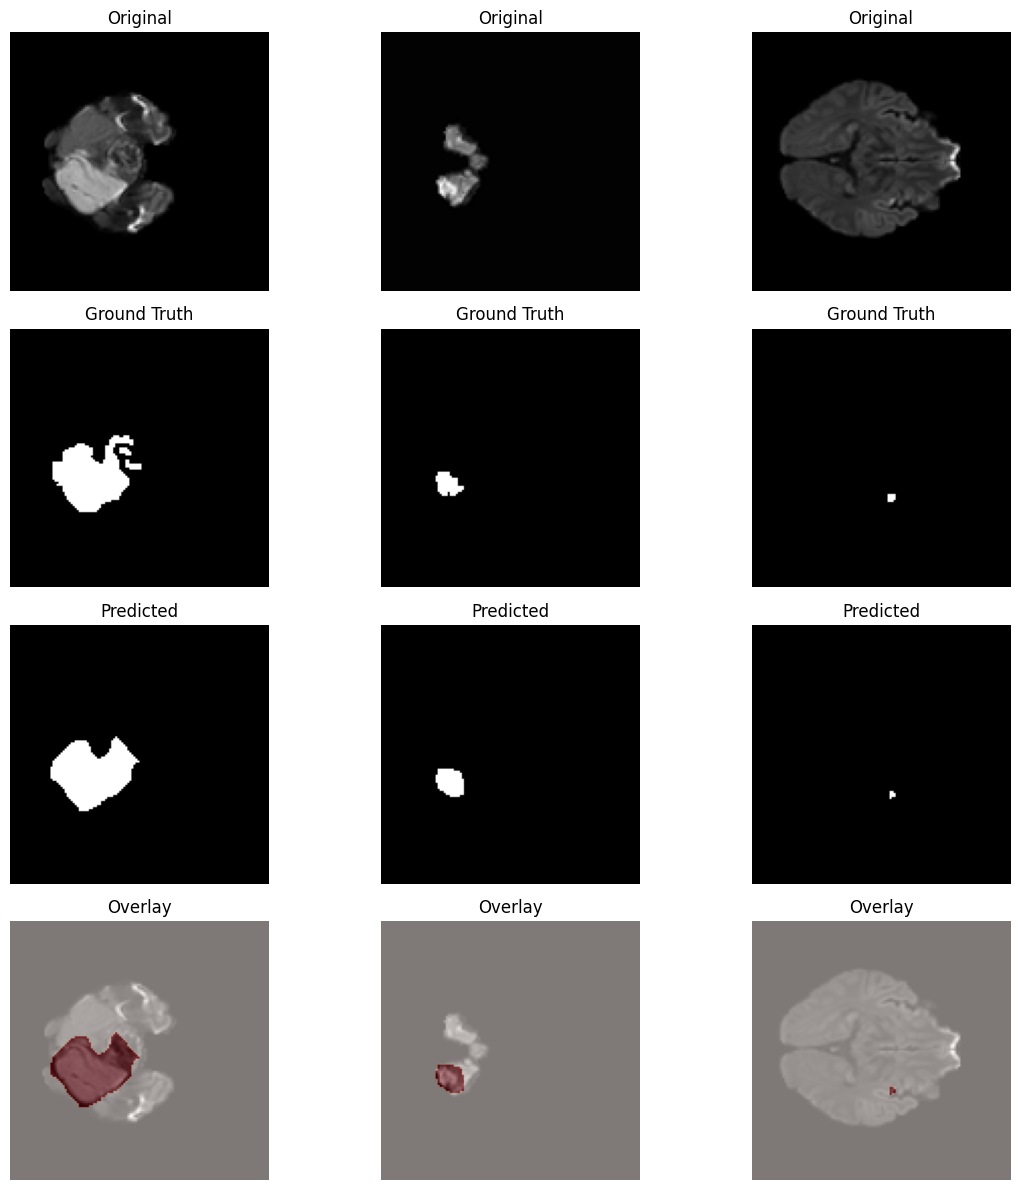

In [1]:
# Resnet + attention unet decoder
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from sklearn.metrics import precision_score, recall_score, f1_score
from torchvision.models.segmentation import deeplabv3_resnet50

# ----------------------------
# Dataset
# ----------------------------
class StrokeDataset(Dataset):
    def __init__(self, image_files, mask_files, transform=None, target_size=(128,128)):
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("L")
        mask  = Image.open(self.mask_files[idx]).convert("L")

        # Resize
        image = image.resize(self.target_size)
        mask  = mask.resize(self.target_size)

        if self.transform:
            image = self.transform(image)
            mask  = self.transform(mask)

        mask = (mask > 0).float()  # binarize mask
        return image, mask

# ----------------------------
# Data loading
# ----------------------------
data_dir = '/kaggle/input/only-slices-with-stroke/'
cases = os.listdir(data_dir)

images, masks = [], []
for case in cases:
    case_path = os.path.join(data_dir, case)
    if os.path.isdir(case_path):
        dwi_files = sorted(glob(os.path.join(case_path, '*dwi*.png')))
        mask_files = sorted(glob(os.path.join(case_path, '*mask*.png')))
        images.extend(dwi_files)
        masks.extend(mask_files)

# Train/Val/Test split: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

transform = transforms.ToTensor()

train_dataset = StrokeDataset(X_train, y_train, transform=transform, target_size=(128,128))
val_dataset   = StrokeDataset(X_val, y_val, transform=transform, target_size=(128,128))
test_dataset  = StrokeDataset(X_test, y_test, transform=transform, target_size=(128,128))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)

# ----------------------------
# Attention Block
# ----------------------------
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True)
        self.W_x = nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True)
        self.psi = nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()
    def forward(self, g, x):
        # g: gating signal (decoder), x: skip connection (encoder)
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        # interpolate if needed
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)
        psi = self.relu(g1 + x1)
        psi = self.sigmoid(self.psi(psi))
        return x * psi

# ----------------------------
# ResNet Encoder + Attention U-Net Decoder
# ----------------------------
class ResNetAttentionUNet(nn.Module):
    def __init__(self, n_classes=1, pretrained=True):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT if pretrained else None)

        # Modify first conv for 1 channel
        self.encoder0 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            resnet.bn1,
            resnet.relu
        )
        self.pool0 = resnet.maxpool
        self.encoder1 = resnet.layer1  # 64
        self.encoder2 = resnet.layer2  # 128
        self.encoder3 = resnet.layer3  # 256
        self.encoder4 = resnet.layer4  # 512

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.dec4 = nn.Sequential(nn.Conv2d(512,256,3,padding=1), nn.ReLU(inplace=True))

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.dec3 = nn.Sequential(nn.Conv2d(256,128,3,padding=1), nn.ReLU(inplace=True))

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec2 = nn.Sequential(nn.Conv2d(128,64,3,padding=1), nn.ReLU(inplace=True))

        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec1 = nn.Sequential(nn.Conv2d(128,64,3,padding=1), nn.ReLU(inplace=True))

        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        # Encoder
        e0 = self.encoder0(x)
        e1 = self.encoder1(self.pool0(e0))
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)
    
        # Decoder + Attention
        d4 = self.up4(e4)
        e3_att = self.att4(g=d4, x=e3)
        if d4.shape[2:] != e3_att.shape[2:]:
            e3_att = F.interpolate(e3_att, size=d4.shape[2:], mode='bilinear', align_corners=True)
        d4 = self.dec4(torch.cat([d4, e3_att], dim=1))
    
        d3 = self.up3(d4)
        e2_att = self.att3(g=d3, x=e2)
        if d3.shape[2:] != e2_att.shape[2:]:
            e2_att = F.interpolate(e2_att, size=d3.shape[2:], mode='bilinear', align_corners=True)
        d3 = self.dec3(torch.cat([d3, e2_att], dim=1))
    
        d2 = self.up2(d3)
        e1_att = self.att2(g=d2, x=e1)
        if d2.shape[2:] != e1_att.shape[2:]:
            e1_att = F.interpolate(e1_att, size=d2.shape[2:], mode='bilinear', align_corners=True)
        d2 = self.dec2(torch.cat([d2, e1_att], dim=1))
    
        d1 = self.up1(d2)
        e0_att = self.att1(g=d1, x=e0)
        if d1.shape[2:] != e0_att.shape[2:]:
            e0_att = F.interpolate(e0_att, size=d1.shape[2:], mode='bilinear', align_corners=True)
        d1 = self.dec1(torch.cat([d1, e0_att], dim=1))
    
        out = self.final(d1)
    
        # --- Ensure output matches input size ---
        if out.shape[2:] != x.shape[2:]:
            out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=True)
    
        return torch.sigmoid(out)

# ----------------------------
# Loss & Metrics
# ----------------------------
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()
    def forward(self, pred, target):
        return self.bce(pred, target) + dice_loss(pred, target)

def dice_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    return (2*intersection + smooth)/(pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (pred>0.5).float()
    intersection = (pred*target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)


class DeepLabV3(nn.Module):
    def __init__(self, n_classes=1, pretrained=True):
        super().__init__()
        self.model = deeplabv3_resnet50(weights="DEFAULT" if pretrained else None)

        # Replace classifier head for binary segmentation
        in_channels = self.model.classifier[4].in_channels
        self.model.classifier[4] = nn.Conv2d(in_channels, n_classes, kernel_size=1)

        # Modify first conv for 1-channel grayscale input
        old_conv = self.model.backbone.conv1
        self.model.backbone.conv1 = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias
        )

    def forward(self, x):
        out = self.model(x)["out"]  # DeepLabv3 returns a dict
        return torch.sigmoid(out)   # same shape as U-Net output


# ----------------------------
# Training
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model = ResNetAttentionUNet(n_classes=1, pretrained=True).to(device)
model = DeepLabV3(n_classes=1, pretrained=True).to(device)

criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 50

train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, running_dice = 0,0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*imgs.size(0)
        running_dice += dice_score(outputs, masks).item()*imgs.size(0)
    train_loss = running_loss/len(train_loader.dataset)
    train_dice = running_dice/len(train_loader.dataset)
    train_losses.append(train_loss)
    train_dice_scores.append(train_dice)

    # Validation
    model.eval()
    val_loss, val_dice = 0,0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()*imgs.size(0)
            val_dice += dice_score(outputs, masks).item()*imgs.size(0)
    val_loss /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)
    val_losses.append(val_loss)
    val_dice_scores.append(val_dice)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")

# ----------------------------
# Plot Training Curves
# ----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves"); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_dice_scores, label='Train Dice')
plt.plot(val_dice_scores, label='Val Dice')
plt.xlabel("Epoch"); plt.ylabel("Dice Score"); plt.title("Dice Score Curves"); plt.legend()
plt.show()

# ----------------------------
# Test Evaluation (All Metrics)
# ----------------------------
model.eval()
all_preds, all_masks = [], []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds_bin = (outputs>0.5).float()
        all_preds.append(preds_bin.cpu())
        all_masks.append(masks.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_masks = torch.cat(all_masks, dim=0)

# Dice, IoU
dice_scores = [dice_score(all_preds[i], all_masks[i]).item() for i in range(len(all_masks))]
iou_scores  = [iou_score(all_preds[i], all_masks[i]).item() for i in range(len(all_masks))]

# Flatten for precision/recall/f1
pred_flat = all_preds.view(-1).numpy()
mask_flat = all_masks.view(-1).numpy()

precision = precision_score(mask_flat, pred_flat)
recall = recall_score(mask_flat, pred_flat)
f1 = f1_score(mask_flat, pred_flat)

print(f"Test Metrics:\n"
      f"Average Dice: {sum(dice_scores)/len(dice_scores):.4f}\n"
      f"Average IoU: {sum(iou_scores)/len(iou_scores):.4f}\n"
      f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

# ----------------------------
# Visualize Test Results
# ----------------------------
plt.figure(figsize=(12,12))
for i in range(min(3, len(all_preds))):
    plt.subplot(4,3,i+1)
    plt.imshow(test_dataset[i][0].squeeze(), cmap='gray'); plt.title("Original"); plt.axis('off')
    plt.subplot(4,3,i+4)
    plt.imshow(test_dataset[i][1].squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(4,3,i+7)
    plt.imshow(all_preds[i].squeeze(), cmap='gray'); plt.title("Predicted"); plt.axis('off')
    plt.subplot(4,3,i+10)
    plt.imshow(test_dataset[i][0].squeeze(), cmap='gray')
    plt.imshow(all_preds[i].squeeze(), alpha=0.5, cmap='Reds'); plt.title("Overlay"); plt.axis('off')
plt.tight_layout()
plt.show()

In [1]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q supervision

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 4.0 MB/s eta 0:00:0000:01


In [4]:
!wget -O sam_vit_h_4b8939.pth "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"


--2025-09-22 21:35:37--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.225.143.109, 13.225.143.122, 13.225.143.99, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.225.143.109|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   322MB/s    in 7.9s    

2025-09-22 21:35:45 (310 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



  Preparing metadata (setup.py) ... done
Test Metrics:
Average Dice: 0.0470
Average IoU: 0.0295
Precision: 0.0235, Recall: 0.3472, F1-score: 0.0440


IndexError: index 1 is out of bounds for dimension 0 with size 1

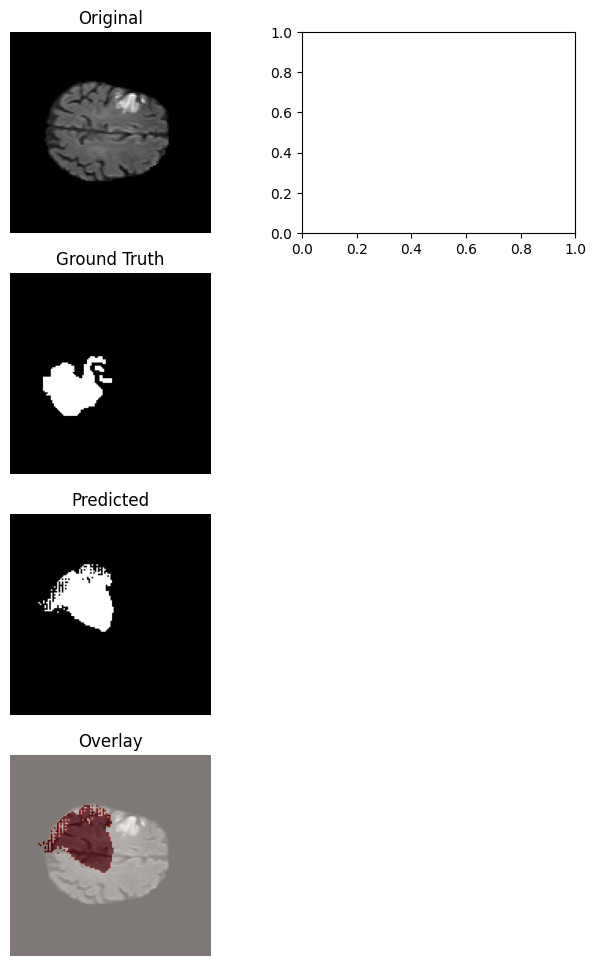

In [6]:
# =========================
# Kaggle-ready SAM Segmentation Pipeline
# =========================

# 1️⃣ Install SAM (only need to run once)
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

# 2️⃣ Imports
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from segment_anything import SamPredictor, sam_model_registry
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# 3️⃣ Dataset Class
class StrokeDataset(Dataset):
    def __init__(self, image_files, mask_files, transform=None, target_size=(128,128)):
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("RGB")  # SAM expects RGB
        mask  = Image.open(self.mask_files[idx]).convert("L")

        image = image.resize(self.target_size)
        mask  = mask.resize(self.target_size)

        if self.transform:
            image = self.transform(image)
            mask  = self.transform(mask)

        mask = (mask > 0).float()  # binarize mask
        return image, mask

# 4️⃣ Prepare Dataset
data_dir = '/kaggle/input/only-slices-with-stroke/'
cases = os.listdir(data_dir)

images, masks = [], []
for case in cases:
    case_path = os.path.join(data_dir, case)
    if os.path.isdir(case_path):
        dwi_files = sorted(glob(os.path.join(case_path, '*dwi*.png')))
        mask_files = sorted(glob(os.path.join(case_path, '*mask*.png')))
        images.extend(dwi_files)
        masks.extend(mask_files)

# Train/Val/Test split
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

transform = transforms.ToTensor()
train_dataset = StrokeDataset(X_train, y_train, transform=transform)
val_dataset   = StrokeDataset(X_val, y_val, transform=transform)
test_dataset  = StrokeDataset(X_test, y_test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1)
test_loader  = DataLoader(test_dataset, batch_size=1)

# 5️⃣ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 6️⃣ Download & Load SAM small model
!wget -q -O sam_vit_b_01ec64.pth "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)
predictor = SamPredictor(sam)

# 7️⃣ Evaluation Functions
def dice_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2.*intersection + smooth)/(pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth)/(union + smooth)

# 8️⃣ Inference & Evaluation
all_preds, all_masks = [], []

for imgs, masks in test_loader:
    img_tensor = imgs[0].to(device)
    mask_tensor = masks[0]

    # Convert to HWC uint8 for SAM
    img_np = (img_tensor.permute(1,2,0).cpu().numpy()*255).astype(np.uint8)

    predictor.set_image(img_np)

    # Prompt: center point for zero-shot
    input_points = np.array([[img_np.shape[0]//2, img_np.shape[1]//2]])
    input_labels = np.array([1])

    masks_pred, _, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=False
    )

    masks_pred = torch.tensor(masks_pred[0]).unsqueeze(0).float()  # [1,H,W]
    all_preds.append(masks_pred)
    all_masks.append(mask_tensor)

# Stack results
preds = torch.stack(all_preds)
masks = torch.stack(all_masks)

# Metrics
dice_scores = [dice_score(preds[i], masks[i]).item() for i in range(len(masks))]
iou_scores  = [iou_score(preds[i], masks[i]).item() for i in range(len(masks))]

pred_flat = (preds>0.5).view(-1).cpu().numpy()
mask_flat = masks.view(-1).cpu().numpy()

precision = precision_score(mask_flat, pred_flat)
recall = recall_score(mask_flat, pred_flat)
f1 = f1_score(mask_flat, pred_flat)

print(f"Test Metrics:\nAverage Dice: {sum(dice_scores)/len(dice_scores):.4f}\n"
      f"Average IoU: {sum(iou_scores)/len(iou_scores):.4f}\n"
      f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

# 9️⃣ Visualization
plt.figure(figsize=(12,12))
for i in range(min(3, len(preds))):
    plt.subplot(4,3,i+1)
    plt.imshow(imgs[i].squeeze().permute(1,2,0))
    plt.title("Original"); plt.axis('off')

    plt.subplot(4,3,i+4)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.title("Ground Truth"); plt.axis('off')

    plt.subplot(4,3,i+7)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title("Predicted"); plt.axis('off')

    plt.subplot(4,3,i+10)
    plt.imshow(imgs[i].squeeze().permute(1,2,0))
    plt.imshow(preds[i].squeeze(), alpha=0.5, cmap='Reds')
    plt.title("Overlay"); plt.axis('off')

plt.tight_layout()
plt.show()



  Preparing metadata (setup.py) ... done
Test Metrics:
Average Dice: 0.0470
Average IoU: 0.0295
Precision: 0.0235, Recall: 0.3472, F1-score: 0.0440


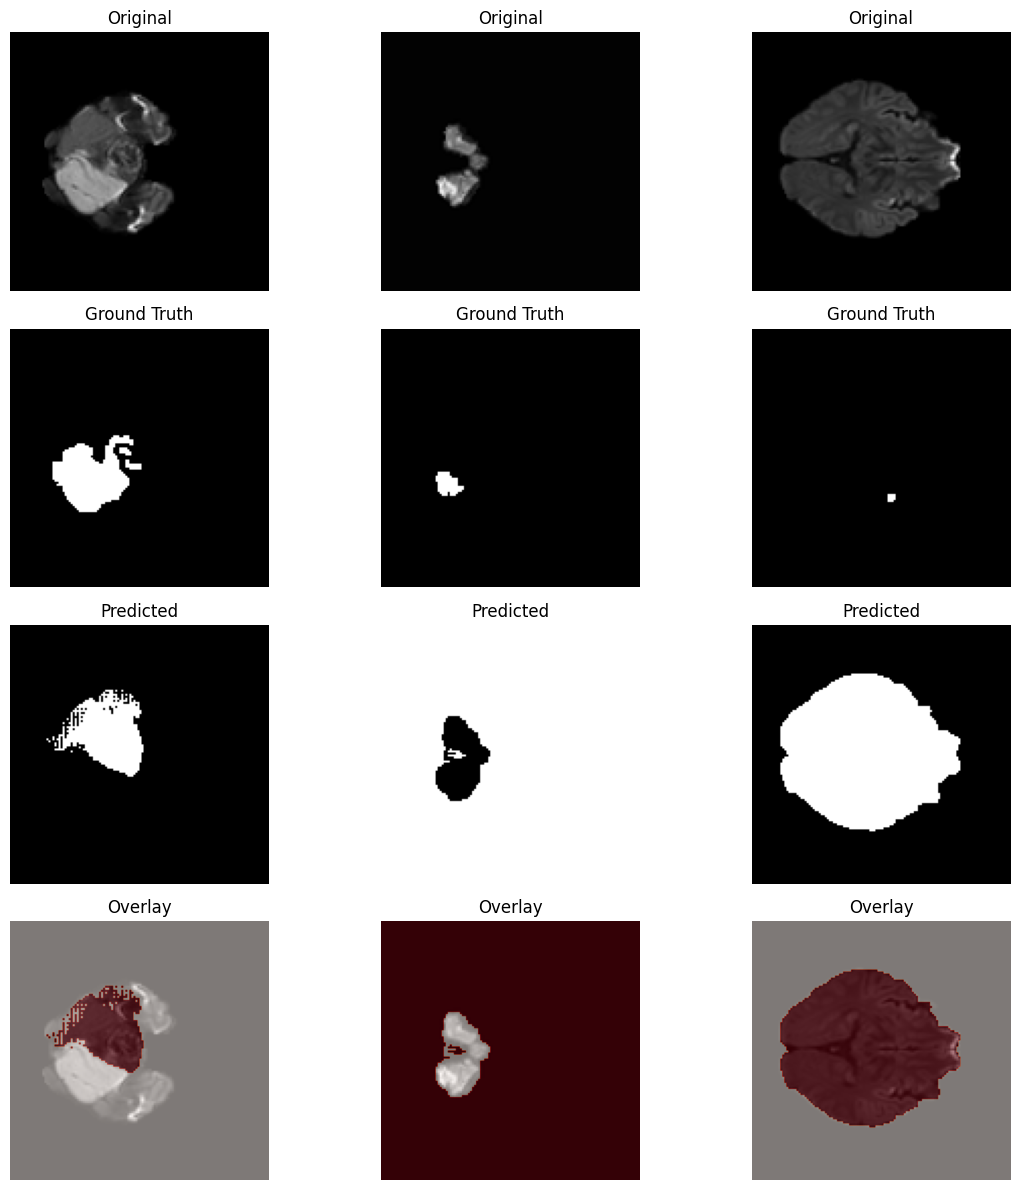

In [12]:
# =========================
# Kaggle-ready SAM Segmentation Pipeline (Fixed Plotting)
# =========================

# 1️⃣ Install SAM
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

# 2️⃣ Imports
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from segment_anything import SamPredictor, sam_model_registry
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# 3️⃣ Dataset Class
class StrokeDataset(Dataset):
    def __init__(self, image_files, mask_files, transform=None, target_size=(128,128)):
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("RGB")  # SAM expects RGB
        mask  = Image.open(self.mask_files[idx]).convert("L")

        image = image.resize(self.target_size)
        mask  = mask.resize(self.target_size)

        if self.transform:
            image = self.transform(image)
            mask  = self.transform(mask)

        mask = (mask > 0).float()  # binarize mask
        return image, mask

# 4️⃣ Prepare Dataset
data_dir = '/kaggle/input/only-slices-with-stroke/'
cases = os.listdir(data_dir)

images, masks = [], []
for case in cases:
    case_path = os.path.join(data_dir, case)
    if os.path.isdir(case_path):
        dwi_files = sorted(glob(os.path.join(case_path, '*dwi*.png')))
        mask_files = sorted(glob(os.path.join(case_path, '*mask*.png')))
        images.extend(dwi_files)
        masks.extend(mask_files)

# Train/Val/Test split
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

transform = transforms.ToTensor()
train_dataset = StrokeDataset(X_train, y_train, transform=transform)
val_dataset   = StrokeDataset(X_val, y_val, transform=transform)
test_dataset  = StrokeDataset(X_test, y_test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1)
test_loader  = DataLoader(test_dataset, batch_size=1)

# 5️⃣ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 6️⃣ Download & Load SAM small model
!wget -q -O sam_vit_b_01ec64.pth "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)
predictor = SamPredictor(sam)

# 7️⃣ Evaluation Functions
def dice_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2.*intersection + smooth)/(pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth)/(union + smooth)

# 8️⃣ Inference & Evaluation
all_preds, all_masks, all_imgs = [], [], []

for imgs, masks in test_loader:
    img_tensor = imgs[0].to(device)
    mask_tensor = masks[0].float()  # ensure float

    all_imgs.append(img_tensor.cpu())  # save original for plotting

    # Convert to HWC uint8 for SAM
    img_np = (img_tensor.permute(1,2,0).cpu().numpy()*255).astype(np.uint8)
    predictor.set_image(img_np)

    # Prompt: center point for zero-shot
    input_points = np.array([[img_np.shape[0]//2, img_np.shape[1]//2]])
    input_labels = np.array([1])

    masks_pred, _, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=False
    )

    masks_pred = torch.tensor(masks_pred[0]).unsqueeze(0).float()  # [1,H,W]
    all_preds.append(masks_pred)
    all_masks.append(mask_tensor)

# Stack results
preds = torch.stack(all_preds)
masks = torch.stack(all_masks)

# Metrics
dice_scores = [dice_score(preds[i], masks[i]).item() for i in range(len(masks))]
iou_scores  = [iou_score(preds[i], masks[i]).item() for i in range(len(masks))]

pred_flat = (preds>0.5).view(-1).cpu().numpy()
mask_flat = masks.view(-1).cpu().numpy()

precision = precision_score(mask_flat, pred_flat)
recall = recall_score(mask_flat, pred_flat)
f1 = f1_score(mask_flat, pred_flat)

print(f"Test Metrics:\nAverage Dice: {sum(dice_scores)/len(dice_scores):.4f}\n"
      f"Average IoU: {sum(iou_scores)/len(iou_scores):.4f}\n"
      f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

# 9️⃣ Visualization
plt.figure(figsize=(12,12))
for i in range(min(3, len(preds))):
    # Original
    plt.subplot(4,3,i+1)
    plt.imshow(all_imgs[i].squeeze().permute(1,2,0))
    plt.title("Original"); plt.axis('off')

    # Ground Truth
    plt.subplot(4,3,i+4)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.title("Ground Truth"); plt.axis('off')

    # Predicted
    plt.subplot(4,3,i+7)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title("Predicted"); plt.axis('off')

    # Overlay
    plt.subplot(4,3,i+10)
    plt.imshow(all_imgs[i].squeeze().permute(1,2,0))
    plt.imshow(preds[i].squeeze(), alpha=0.5, cmap='Reds')
    plt.title("Overlay"); plt.axis('off')

plt.tight_layout()
plt.show()
